### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
import kagglehub
import pandas as pd
import sys
sys.path.append('./utils')

In [40]:
df=pd.read_csv('./drawing-with-llms/description_master_gpt_deepseek_10k.csv')
print(df.shape)
df.head()

(10735, 1)


,description
0,a red barn in a golden wheat field
1,a winding cobblestone path through an autumn f...
2,a turquoise river cutting through a canyon
3,a cluster of white birch trees in a misty meadow
4,a lone oak tree on a grassy hill at sunset


In [42]:
import pandas as pd

# Keep only rows where the description is a string
df = df[df['description'].apply(lambda x: isinstance(x, str))].copy()

# Strip whitespace from start and end
df['description'] = df['description'].str.strip()

# Remove rows that are numeric (e.g., floats or ints as strings like "123" or "45.6")
df = df[~df['description'].str.replace('.', '', 1).str.isnumeric()]

# Optional: drop empty rows
df = df[df['description'] != '']

# Reset index
df.reset_index(drop=True, inplace=True)

print(df.shape)
df.head()



(10733, 1)


,description
0,a red barn in a golden wheat field
1,a winding cobblestone path through an autumn f...
2,a turquoise river cutting through a canyon
3,a cluster of white birch trees in a misty meadow
4,a lone oak tree on a grassy hill at sunset


In [43]:
# Character length of each description
df['char_length'] = df['description'].str.len()

# Word count per description
df['word_count'] = df['description'].str.split().str.len()

# Average character and word count
print("Average char length:", df['char_length'].mean())
print("Average word count:", df['word_count'].mean())


Average char length: 33.29236932824001
Average word count: 5.776483741731109


<Axes: >

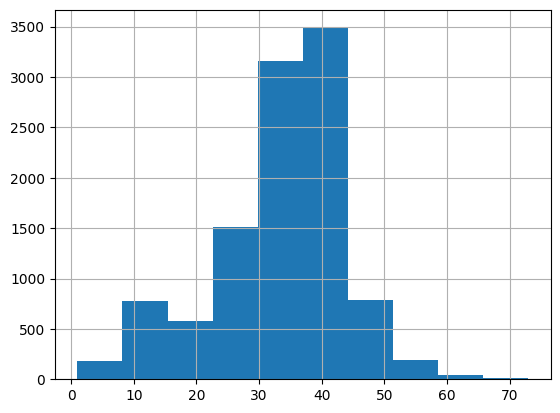

In [44]:
df['char_length'].hist()

<Axes: >

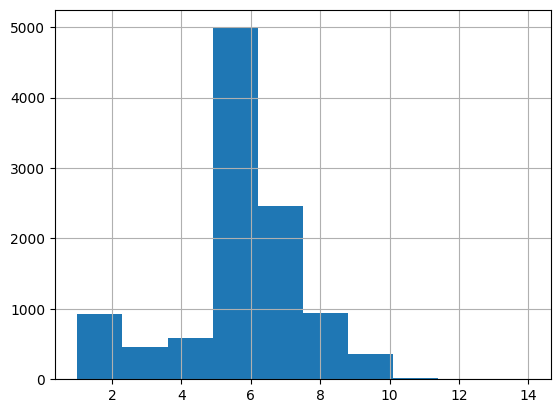

In [45]:
df['word_count'].hist()

In [46]:
from collections import Counter

# Flatten all words
all_words = ' '.join(df['description']).lower().split()
word_freq = Counter(all_words)

# Top 10 common words
print(word_freq.most_common(10))


[('a', 7396), ('with', 3259), ('of', 2879), ('"a', 2745), ('in', 1888), ('pair', 718), ('abstract', 582), ('glowing', 465), ('leather', 435), ('under', 361)]


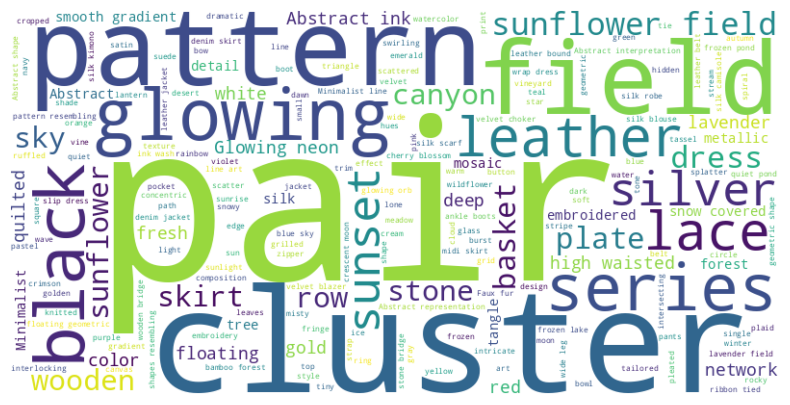

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['description'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['description'])

# Cosine similarity between descriptions
cos_sim = cosine_similarity(tfidf_matrix)

# Example: most similar to first description
similar_idx = cos_sim[0].argsort()[::-1][1:6]
print("Most similar to row 0:\n", df.iloc[similar_idx]['description'])


Most similar to row 0:
 323           a red barn under a golden sunset
5717                               wheat field
4377        a sunset over a golden wheat field
7577     A windmill in a field of golden wheat
9298    A quiet wheat field under a golden sky
Name: description, dtype: object


In [53]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Get POS tags
df['pos_tags'] = df['description'].apply(lambda x: nltk.pos_tag(nltk.word_tokenize(x)))

# Count of nouns, verbs, etc.
def count_pos(pos_tags, tag_prefix):
    return sum(1 for word, tag in pos_tags if tag.startswith(tag_prefix))

df['noun_count'] = df['pos_tags'].apply(lambda tags: count_pos(tags, 'NN'))
df['verb_count'] = df['pos_tags'].apply(lambda tags: count_pos(tags, 'VB'))

print(df[['description', 'noun_count', 'verb_count']].head())


[nltk_data] Downloading package punkt to /home/vino/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/vino/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


                                         description  noun_count  verb_count
0                 a red barn in a golden wheat field           3           0
1  a winding cobblestone path through an autumn f...           4           1
2         a turquoise river cutting through a canyon           3           1
3   a cluster of white birch trees in a misty meadow           5           0
4         a lone oak tree on a grassy hill at sunset           6           0


In [54]:
df.head()

,description,char_length,word_count,pos_tags,noun_count,verb_count
0,a red barn in a golden wheat field,34,8,"[(a, DT), (red, JJ), (barn, NN), (in, IN), (a,...",3,0
1,a winding cobblestone path through an autumn f...,51,8,"[(a, DT), (winding, VBG), (cobblestone, NN), (...",4,1
2,a turquoise river cutting through a canyon,42,7,"[(a, DT), (turquoise, NN), (river, NN), (cutti...",3,1
3,a cluster of white birch trees in a misty meadow,48,10,"[(a, DT), (cluster, NN), (of, IN), (white, JJ)...",5,0
4,a lone oak tree on a grassy hill at sunset,42,10,"[(a, DT), (lone, NN), (oak, NN), (tree, NN), (...",6,0


In [56]:
# Extract nouns and verbs as lists
df['nouns'] = df['pos_tags'].apply(lambda tags: [word for word, tag in tags if tag.startswith('NN')])
df['verbs'] = df['pos_tags'].apply(lambda tags: [word for word, tag in tags if tag.startswith('VB')])

df.head(2)


,description,char_length,word_count,pos_tags,noun_count,verb_count,nouns,verbs
0,a red barn in a golden wheat field,34,8,"[(a, DT), (red, JJ), (barn, NN), (in, IN), (a,...",3,0,"[barn, wheat, field]",[]
1,a winding cobblestone path through an autumn f...,51,8,"[(a, DT), (winding, VBG), (cobblestone, NN), (...",4,1,"[cobblestone, path, autumn, forest]",[winding]


In [57]:
# Flatten all nouns and verbs into two separate lists
all_nouns = [noun for row in df['nouns'] for noun in row]
all_verbs = [verb for row in df['verbs'] for verb in row]

# Optional: check top few
print("Nouns:", all_nouns[:10])
print("Verbs:", all_verbs[:10])


Nouns: ['barn', 'wheat', 'field', 'cobblestone', 'path', 'autumn', 'forest', 'turquoise', 'river', 'canyon']
Verbs: ['winding', 'cutting', 'reflecting', 'crashing', 'cascading', 'stretching', 'rolling', 'teeming', 'towering', 'piercing']


In [63]:
# Remove duplicates by converting to a set and back to a list
unique_nouns = list(set(all_nouns))
unique_verbs = list(set(all_verbs))

In [69]:
import numpy as np
import pandas as pd

# Find the max length
max_len = max(len(unique_nouns), len(unique_verbs))

# Pad shorter array with NaN (or any value you prefer)
unique_nouns_padded = unique_nouns + [np.nan] * (max_len - len(unique_nouns))
unique_verbs_padded = unique_verbs + [np.nan] * (max_len - len(unique_verbs))

# Create DataFrame with padded lists
unique_df = pd.DataFrame({
    'nouns': unique_nouns_padded,
    'verbs': unique_verbs_padded
})

unique_df.head(2)
#unique_df.to_csv('unique_df.csv',index=False)

In [70]:
df=df[df['word_count'] >3]

In [71]:
df.shape

(9359, 8)

In [76]:
df.to_csv('tmp.csv',index=False)

In [77]:
df.head()

,description,char_length,word_count,pos_tags,noun_count,verb_count,nouns,verbs
0,a red barn in a golden wheat field,34,8,"[(a, DT), (red, JJ), (barn, NN), (in, IN), (a,...",3,0,"[barn, wheat, field]",[]
1,a winding cobblestone path through an autumn f...,51,8,"[(a, DT), (winding, VBG), (cobblestone, NN), (...",4,1,"[cobblestone, path, autumn, forest]",[winding]
2,a turquoise river cutting through a canyon,42,7,"[(a, DT), (turquoise, NN), (river, NN), (cutti...",3,1,"[turquoise, river, canyon]",[cutting]
3,a cluster of white birch trees in a misty meadow,48,10,"[(a, DT), (cluster, NN), (of, IN), (white, JJ)...",5,0,"[cluster, birch, trees, misty, meadow]",[]
4,a lone oak tree on a grassy hill at sunset,42,10,"[(a, DT), (lone, NN), (oak, NN), (tree, NN), (...",6,0,"[lone, oak, tree, grassy, hill, sunset]",[]
